In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import numpy as np

import jax
import jax.numpy as jnp
from jax import jacrev, vmap

from scipy.spatial import Delaunay

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# === Global Plotting Style ===
plt.style.use('tableau-colorblind10')
plt.rcParams.update({
    'text.usetex': True,
    'font.size': 16,
    'axes.linewidth': 1.2,
    'axes.edgecolor': 'black',
    'xtick.major.size': 5,
    'ytick.major.size': 5
})

import config.config as config

import differential_geometry.aux_tools as aux

import differential_geometry.manifolds as manifolds
import differential_geometry.charts as charts
import differential_geometry.functions as functions

import plotting_tools.plot_manifolds as plot_manifolds
import plotting_tools.plot_charts as plot_charts
import plotting_tools.plot_functions as plot_functions

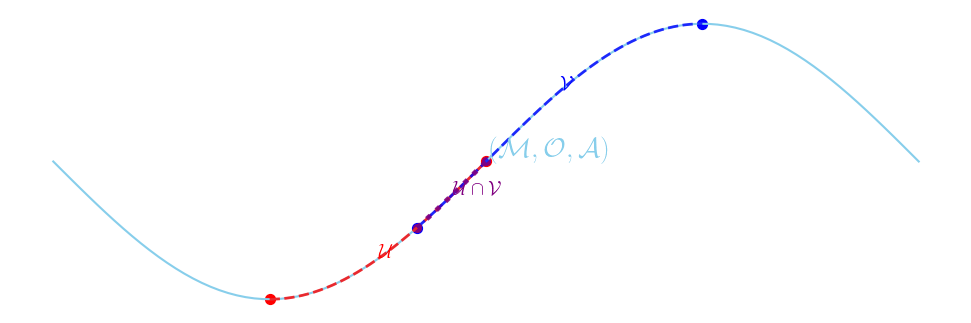

In [2]:
# === Define 1D → 2D manifold ===
def curve_1d_to_2d(t):
    return jnp.array([t[0], jnp.sin(t[0])])

man1 = manifolds.Manifold(1, 2, curve_1d_to_2d)

# === Define Charts as intervals in param space ===
boundary_U = (-jnp.pi + jnp.pi / 2, 0.0)
chart_U = charts.Chart(
    name="U",
    manifold=man1,
    boundary=boundary_U,
    chart_map=lambda t: t  # identity chart map
)

boundary_V = (-0.5, jnp.pi - jnp.pi / 2)
chart_V = charts.Chart(
    name="V",
    manifold=man1,
    boundary=boundary_V,
    chart_map=lambda t: -2*t
)

boundary_U_cap_V = charts.compute_chart_intersection(boundary_U, boundary_V)

chart_U_cap_V_X = charts.Chart(
    name="U_cap_V_X",
    manifold=man1,
    boundary=boundary_U_cap_V,
    chart_map=lambda t: t,
)

chart_U_cap_V_Y = charts.Chart(
    name="U_cap_V_Y",
    manifold=man1,
    boundary=boundary_U_cap_V,
    chart_map=lambda t: -2*t,
)

# === Plot manifold with chart overlays ===
fig, ax = plt.subplots(figsize=(10, 10))

plot_manifolds.plot_manifold(
    ax=ax, manifold=man1, resolution=100, xmin=-jnp.pi, xmax=jnp.pi, ymin=-jnp.pi, ymax=jnp.pi,
    color="skyblue", alpha=1.0, edgecolor="none", label=r"$\left(\mathcal{M}, \mathcal{O}, \mathcal{A}\right)$",
    label_position="center", label_fontsize=20, function=None, cmap="viridis", label_function="Scalar field $f$",
)

plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=man1, chart=chart_U,
    color="red", n_points=512, linestyle="dashed", linewidth=2.0,
    fill_surface=False, alpha=0.8,
    label=r"$\mathcal{U}$", label_position="center", label_fontsize=14,
    draw_endpoints=True, endpoint_color="red", endpoint_size=50,
)
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=man1, chart=chart_V,
    color="blue", n_points=512, linestyle="dashed", linewidth=2.0,
    fill_surface=False, alpha=0.8,
    label=r"$\mathcal{V}$", label_position="center", label_fontsize=14,
    draw_endpoints=True, endpoint_color="blue", endpoint_size=50,
)
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=man1, chart=chart_U_cap_V_X,
    color="purple", n_points=512, linestyle="dotted", linewidth=3.5,
    fill_surface=True, alpha=0.9, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{U} \cap \mathcal{V}$", label_position="bottom", label_fontsize=14,
    draw_endpoints=True, endpoint_color="purple", endpoint_size=30,
)

plt.tight_layout()
plt.show()

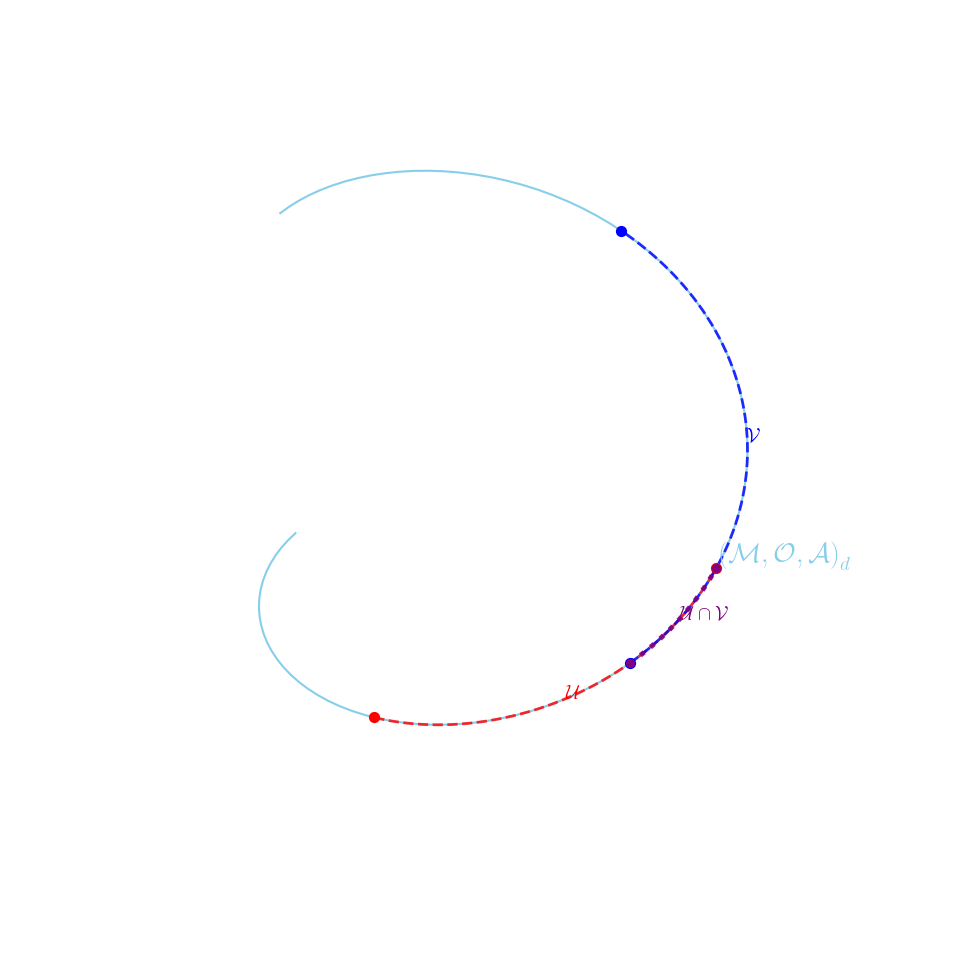

In [3]:
# === Define 1D → 3D manifold ===
def curve_1d_to_3d(t):
    return jnp.array([jnp.cos(t[0]), jnp.sin(t[0]), t[0]])

man2 = manifolds.Manifold(1, 3, curve_1d_to_3d)

# === Define Charts as intervals ===
boundary_U = (-jnp.pi+jnp.pi/2, 0.0)
chart_U = charts.Chart(
    name="U",
    manifold=man2,
    boundary=boundary_U,
    chart_map=lambda t: t
)

boundary_V = (-0.5, jnp.pi-jnp.pi/2)
chart_V = charts.Chart(
    name="V",
    manifold=man2,
    boundary=boundary_V,
    chart_map=lambda t: -2*t
)

boundary_U_cap_V = charts.compute_chart_intersection(boundary_U, boundary_V)

chart_U_cap_V_X = charts.Chart(
    name="U_cap_V_X",
    manifold=man2,
    boundary=boundary_U_cap_V,
    chart_map=lambda t: t,
)

chart_U_cap_V_Y = charts.Chart(
    name="U_cap_V_Y",
    manifold=man2,
    boundary=boundary_U_cap_V,
    chart_map=lambda t: -2*t,
)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

plot_manifolds.plot_manifold(
    ax=ax, manifold=man2, resolution=100, xmin=-jnp.pi, xmax=jnp.pi, ymin=-jnp.pi, ymax=jnp.pi,
    color="skyblue", alpha=1.0, edgecolor="none", label=r"$\left(\mathcal{M}, \mathcal{O}, \mathcal{A}\right)_d$",
    label_position="center", label_fontsize=20, function=None, cmap="viridis",  label_function="Scalar field $f$",
)

plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=man2, chart=chart_U,
    color="red", n_points=512, linestyle="dashed", linewidth=2.0,
    fill_surface=False, alpha=0.8,
    label=r"$\mathcal{U}$", label_position="center", label_fontsize=14,
    draw_endpoints=True, endpoint_color="red", endpoint_size=50,
)
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=man2, chart=chart_V,
    color="blue", n_points=512, linestyle="dashed", linewidth=2.0,
    fill_surface=False, alpha=0.8,
    label=r"$\mathcal{V}$", label_position="center", label_fontsize=14,
    draw_endpoints=True, endpoint_color="blue", endpoint_size=50,
)
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=man2, chart=chart_U_cap_V_X,
    color="purple", n_points=512, linestyle="dotted", linewidth=3.5,
    fill_surface=True, alpha=0.9, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{U} \cap \mathcal{V}$", label_position="bottom", label_fontsize=14,
    draw_endpoints=True, endpoint_color="purple", endpoint_size=30,
)

ax.view_init(elev=50.0, azim=-60.0)
plt.tight_layout()
plt.show()

In [4]:
manifold = manifolds.Manifold(
    param_dim=2, ambient_dim=3,
    embedding_func=manifolds.factory_surface_embedding_gaussian_eggs(
        amplitude=1.0, center=(0.0, 0.0), sigma=(jnp.pi, jnp.pi)
    ),
)


# center_V = jnp.array([0.7, 0.3])
# axes_V = (1.4, 0.9)
# x_center_polar, y_center_polar = -1., -1.

center_V = jnp.array([0.0, 0.0])
axes_V = (jnp.pi / 2, jnp.pi / 2)
x_center_polar, y_center_polar = 0.0, 0.0

polar_center = (x_center_polar, y_center_polar)
lambdas = jnp.linspace(0, 2 * jnp.pi, 600)
boundary_V = charts.boundary_ellipse_in_param_space(lambdas, center=center_V, axes=axes_V)
chart_V = charts.Chart(
    name="V",
    manifold=manifold,
    boundary=np.array(boundary_V),
    chart_map=lambda params: charts.polar_chart_map(params, center=polar_center),
    inverse_chart_map=lambda chart_coords: charts.inverse_polar_chart_map(chart_coords, center=polar_center),
    region_sampler=charts.polar_region_sampler_from_boundary(
        np.array(boundary_V), center=np.array(polar_center)
    )
)


# center_U = jnp.array([0.1, -0.7])
# axes_U = (0.9, 1.5)
# boundary_U = charts.boundary_ellipse_in_param_space(lambdas, center=center_U, axes=axes_U)

lambdas = jnp.linspace(0, 4, 500, endpoint=False)
boundary_U = charts.boundary_rectangle_in_param_space(
    lambdas, xlim=(-jnp.pi / 2, jnp.pi / 2), ylim=(-jnp.pi / 2, jnp.pi / 2)
)

chart_U = charts.Chart(
    name="U",
    manifold=manifold,
    boundary=np.array(boundary_U),
    chart_map=charts.cartesian_chart_map,
    inverse_chart_map=charts.inverse_cartesian_chart_map,
    region_sampler=charts.polar_region_sampler_from_boundary(
        np.array(boundary_U), center=np.array(polar_center)
    )
)



boundary_U_cap_V = charts.compute_chart_intersection(boundary_U, boundary_V)

chart_U_cap_V_X = charts.Chart(
    name="U_cap_V_X",
    manifold=manifold,
    boundary=np.array(boundary_U_cap_V),
    chart_map=charts.cartesian_chart_map,
    inverse_chart_map=charts.inverse_cartesian_chart_map,
    region_sampler=charts.polar_region_sampler_from_boundary(
        np.array(boundary_U_cap_V), center=np.array(polar_center)
    )
)

chart_U_cap_V_Y = charts.Chart(
    name="U_cap_V_Y",
    manifold=manifold,
    boundary=np.array(boundary_U_cap_V),
    chart_map=lambda params: charts.polar_chart_map(params, center=polar_center),
    inverse_chart_map=lambda chart_coords: charts.inverse_polar_chart_map(chart_coords, center=polar_center),
    region_sampler=charts.polar_region_sampler_from_boundary(
        np.array(boundary_U_cap_V), center=np.array(polar_center)
    )
)


def my_function(params):
    x, y = params
    param_points = jnp.stack([x.ravel(), y.ravel()], axis=-1)
    tmp_ = manifold.embed(param_points)
    tmp_x = tmp_[:, 0].reshape(x.shape)
    tmp_y = tmp_[:, 1].reshape(y.shape)
    tmp_z = tmp_[:, 2].reshape(x.shape)
    return tmp_z  * jnp.sqrt(tmp_x**2 + tmp_y**2 + 2.)

function_f = functions.Function(
    manifold=manifold,
    function_parametric=my_function
)

/tmp/ipykernel_483565/2101226442.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


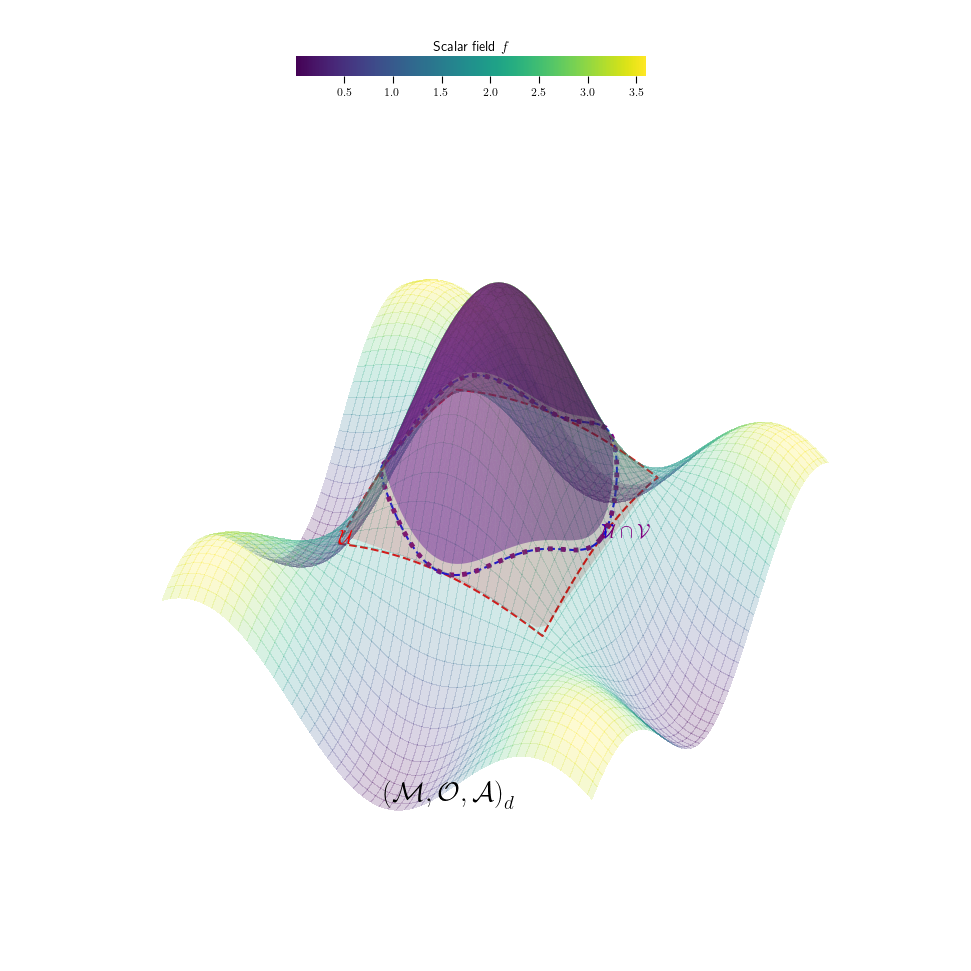

In [5]:
xmin, xmax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3
ymin, ymax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

plot_manifolds.plot_manifold(
    ax=ax, manifold=manifold, resolution=100, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
    color="skyblue", alpha=0.2, edgecolor="none", label=r"$\left(\mathcal{M}, \mathcal{O}, \mathcal{A}\right)_d$",
    label_position="bottom", label_fontsize=20, function=function_f, cmap="viridis",
    label_function="Scalar field $f$", inset_colorbar=True, inset_position=(0.3, 0.93), inset_size=(3.5, 0.2),
    colorbar_orientation="horizontal", label_colorbar_position="top",
    inset_box_alpha=0.8, inset_box_color="white", inset_border_color="black"
)

plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=manifold, chart=chart_U,
    color="red", n_points=2**11, linestyle="dashed", linewidth=1.5,
    fill_surface=True, alpha=0.15, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{U}$", label_position="bottom", label_fontsize=14,
    draw_endpoints=True, endpoint_color="red", endpoint_size=30,
)
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=manifold, chart=chart_V,
    color="blue", n_points=2**12, linestyle="dashed", linewidth=1.5,
    fill_surface=True, alpha=0.15, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{V}$", label_position="bottom", label_fontsize=14,
    draw_endpoints=True, endpoint_color="blue", endpoint_size=30,
)
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=manifold, chart=chart_U_cap_V_X,
    color="purple", n_points=2**12, linestyle="dotted", linewidth=3.5,
    fill_surface=True, alpha=0.3, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{U} \cap \mathcal{V}$", label_position="bottom", label_fontsize=14,
    draw_endpoints=True, endpoint_color="purple", endpoint_size=30,
)

ax.view_init(elev=50.0, azim=-60.0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_483565/4280323820.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


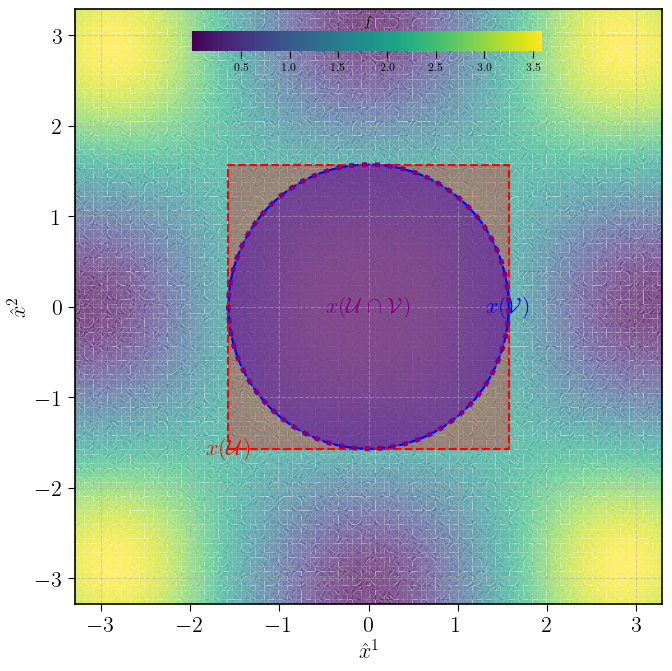

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

x = jnp.linspace(xmin, xmax, 128)
y = jnp.linspace(ymin, ymax, 128)
x, y = jnp.meshgrid(x, y)
param_points = jnp.stack([x.ravel(), y.ravel()], axis=-1)
param_points = np.array(param_points)
# param_points = np.array(chart_U.sample_region_in_param_space(n_points=2**13))
function_values = np.array(function_f.evaluate_in_param_space(param_points))
tri = Delaunay(param_points)
plot_functions.plot_parametric_function_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=param_points, function_values=function_values, cmap="viridis",
    alpha=0.7, linewidth=0.01, label=None, label_position="top", label_fontsize=16,
    simplices=tri.simplices, inset_colorbar=True, inset_position=(0.2, 0.93), inset_size=(3.5, 0.2),
    colorbar_orientation="horizontal", label_colorbar=r"$f$", label_colorbar_position="top",
    inset_box_alpha=1.0, inset_box_color="white", inset_border_color="black"
)

plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_U.boundary_curve, color="red", linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$x(\mathcal{U})$", label_position="bottom",
    label_fontsize=16, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color="red", boundary_marker_size=8
)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_V.boundary_curve, color="blue", linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$x(\mathcal{V})$", label_position="right",
    label_fontsize=16, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color="blue", boundary_marker_size=8
)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_U_cap_V_X.boundary_curve, color="purple", linestyle="dotted",
    linewidth=3.5, alpha=0.3, label=r"$x(\mathcal{U} \cap \mathcal{V})$", label_position="center",
    label_fontsize=16, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color="purple", boundary_marker_size=8
)

ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), xlabel=r"$\hat{x}^1$", ylabel=r"$\hat{x}^2$")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_483565/3027676825.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


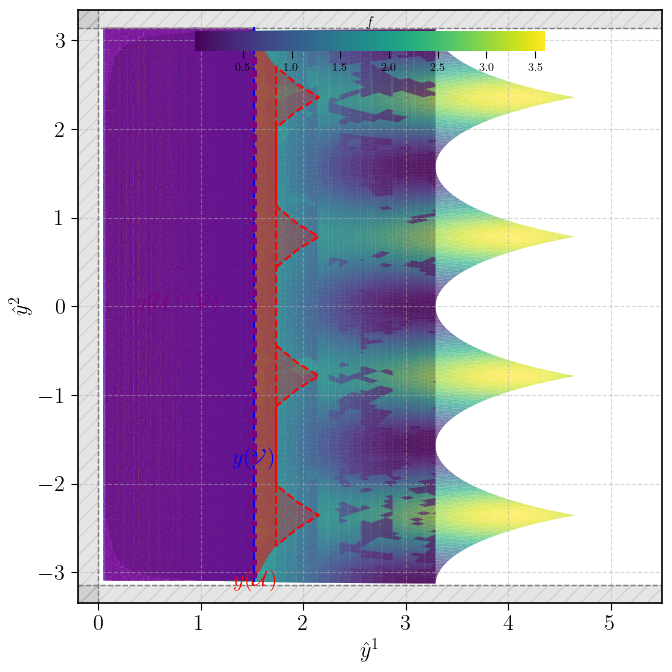

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

x = jnp.linspace(xmin, xmax, 64)
y = jnp.linspace(ymin, ymax, 64)
x, y = jnp.meshgrid(x, y)
param_points = jnp.stack([x.ravel(), y.ravel()], axis=-1)
param_points = np.array(param_points)
# param_points = np.array(chart_V.sample_region_in_param_space(n_points=2**13))
function_values = np.array(function_f.evaluate_in_param_space(param_points))
tri = Delaunay(param_points)
plot_functions.plot_parametric_function_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=param_points, function_values=function_values, cmap="viridis",
    alpha=0.7, linewidth=0.01, label=None, label_position="top", label_fontsize=16,
    simplices=tri.simplices, inset_colorbar=True, inset_position=(0.2, 0.93), inset_size=(3.5, 0.2),
    colorbar_orientation="horizontal", label_colorbar=r"$f$", label_colorbar_position="top",
    inset_box_alpha=1.0, inset_box_color="white", inset_border_color="black"
)

param_points = np.array(chart_U.sample_region_in_param_space(n_points=2**12))
tri = Delaunay(param_points)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=param_points, color="red", linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$y(\mathcal{U})$", label_position="bottom",
    label_fontsize=16, tessellated=True, simplices=tri.simplices, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color="red", boundary_marker_size=8
)
param_points = np.array(chart_V.sample_region_in_param_space(n_points=2**12))
tri = Delaunay(param_points)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=param_points, color="blue", linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$y(\mathcal{V})$", label_position="right",
    label_fontsize=16, tessellated=True, simplices=tri.simplices, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color="blue", boundary_marker_size=8
)
param_points = np.array(chart_U_cap_V_X.sample_region_in_param_space(n_points=2**12))
tri = Delaunay(param_points)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=param_points, color="purple", linestyle="dotted",
    linewidth=3.5, alpha=0.3, label=r"$y(\mathcal{U} \cap \mathcal{V})$", label_position="center",
    label_fontsize=16, tessellated=True, simplices=tri.simplices, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color="purple", boundary_marker_size=8
)

ax.set(xlim=(-0.2, 5.5), ylim=(-np.pi-0.2, np.pi+0.2),
       xlabel=r"$\hat{y}^1$", ylabel=r"$\hat{y}^2$")
ax.axvspan(-1, 0, color='grey', alpha=0.2, hatch='//')
ax.axhspan(np.pi, np.pi+1, color='grey', alpha=0.2, hatch='//')
ax.axhspan(-np.pi-1, -np.pi, color='grey', alpha=0.2, hatch='//')
ax.axhline(np.pi, color='gray', ls='--', lw=1)
ax.axhline(-np.pi, color='gray', ls='--', lw=1)
ax.axvline(0, color='gray', ls='--', lw=1)
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()